In [12]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from lightgbm import LGBMRegressor
from sklearn.metrics import r2_score

from sklearn.metrics import mean_squared_error
import numpy as np

In [4]:
# 1) 데이터 불러오기
df = pd.read_csv("../csv-data/korea_apartment_sample.csv")


# 2) X(입력), y(타깃) 분리
X = df.drop("거래금액_만원", axis=1)
y = df["거래금액_만원"]

In [5]:
X

,지역코드,거래연도,거래월,전용면적,층,건물연식,세대수,지하철거리_km,지역소득_백만원,학군점수
0,1,2020,5,129.193131,31,2,486,2.473376,6.098772,1.067025
1,4,2015,3,120.466961,15,3,830,2.563601,10.264941,3.716797
2,3,2023,3,49.906979,9,24,1606,2.407747,8.197957,1.306273
3,2,2015,1,37.073566,23,37,1476,3.177218,12.291632,2.683045
4,0,2019,12,132.847062,19,14,1126,0.453609,13.231019,3.406729
...,...,...,...,...,...,...,...,...,...,...
495,1,2022,9,70.239909,9,38,1833,1.933101,9.917669,2.406169
496,2,2021,7,93.377342,20,0,1320,3.312420,12.142603,3.441510
497,0,2022,7,44.931719,1,16,716,1.734813,12.378068,1.096441
498,4,2020,11,47.528196,8,40,595,1.953776,6.309089,1.465836


In [6]:
y

0      76628
1      89874
2      53557
3      46731
4      81917
       ...  
495    49232
496    72429
497    40979
498    50275
499    70459
Name: 거래금액_만원, Length: 500, dtype: int64

In [7]:
# 3) Train/Test 분리
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [8]:
# 4) 모델 학습 (랜덤포레스트)
model = RandomForestRegressor(n_estimators=300, random_state=42)
model.fit(X_train, y_train)

RandomForestRegressor(n_estimators=300, random_state=42)

In [11]:
model2 = LGBMRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=-1,
    random_state=42
)
model2.fit(X_train, y_train)

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000091 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 775
[LightGBM] [Info] Number of data points in the train set: 400, number of used features: 10
[LightGBM] [Info] Start training from score 65260.500000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain

LGBMRegressor(learning_rate=0.05, n_estimators=500, random_state=42)

In [13]:
model3 = LinearRegression()
model3.fit(X_train, y_train)

LinearRegression()

In [16]:
y_pred = model.predict(X_test)
y_pred2 = model2.predict(X_test)
y_pred3 = model3.predict(X_test)

In [17]:
r2_1 = r2_score(y_test, y_pred)
r2_2 = r2_score(y_test, y_pred2)
r2_3 = r2_score(y_test, y_pred3)

In [37]:
print("랜덤포레스트 r2 :", r2_1)
print("LightGBM r2 :", r2_2)
print("Linear r2 :", r2_3)

랜덤포레스트 r2 : 0.8697170262583864
LightGBM r2 : 0.8961431606541058
Linear r2 : 0.9141322336831014


In [28]:
# MSE 각각 구해보세요.
# RMSE는 함수가 없음. MSE를 구한 다음 np.sqrt()를 이용해서 구해보세요.
mse1 = mean_squared_error(y_test, y_pred)
rmse1 = np.sqrt(mse1)

mse2 = mean_squared_error(y_test, y_pred2)
rmse2 = np.sqrt(mse2)

mse3 = mean_squared_error(y_test, y_pred3)
rmse3 = np.sqrt(mse3)

In [30]:
print("랜덤포레스트 rmse :", rmse1)
print("LightGBM rmse :", rmse2)
print("Linear rmse :", rmse3)

랜덤포레스트 rmse : 6133.67716100873
LightGBM rmse : 5476.39333270323
Linear rmse : 4979.573706452671


In [31]:
X.columns

Index(['지역코드', '거래연도', '거래월', '전용면적', '층', '건물연식', '세대수', '지하철거리_km',
       '지역소득_백만원', '학군점수'],
      dtype='object')

In [33]:
df.describe()

,지역코드,거래연도,거래월,전용면적,층,건물연식,세대수,지하철거리_km,지역소득_백만원,학군점수,거래금액_만원
count,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000
mean,1.744000,2019.350000,6.510000,85.033916,18.402000,20.672000,1070.716000,2.507253,9.236773,2.917440,65280.310000
std,1.306092,2.892098,3.489736,35.872916,9.949794,12.192035,569.519528,1.405936,3.437694,1.158624,16896.815303
min,0.000000,2015.000000,1.000000,20.043226,1.000000,0.000000,52.000000,0.010093,3.037691,1.000746,20048.000000
25%,1.000000,2017.000000,3.000000,53.354638,10.000000,10.000000,568.750000,1.354169,6.300938,1.934232,51436.250000
50%,2.000000,2019.000000,7.000000,87.366605,19.000000,21.000000,1102.000000,2.506508,9.607319,2.857360,67137.000000
75%,3.000000,2022.000000,10.000000,114.197256,27.000000,32.000000,1598.750000,3.720027,12.272790,3.922635,77599.000000
max,4.000000,2024.000000,12.000000,149.412464,35.000000,40.000000,2000.000000,4.997720,14.956780,4.990491,110460.000000


In [36]:
price1 = model.predict([[1, 2025, 11, 87.366605, 10, 15, 500, 1, 2, 3]])
price2 = model2.predict([[1, 2025, 11, 87.366605, 10, 15, 500, 1, 2, 3]])
price3 = model3.predict([[1, 2025, 11, 87.366605, 10, 15, 500, 1, 2, 3]])

price1, price2, price3

(array([60896.81666667]), array([60731.6341193]), array([59517.49267737]))

In [38]:
### stacking ###

In [55]:
from sklearn.linear_model import LinearRegression
from sklearn.discriminant_analysis import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.tree import DecisionTreeRegressor
from sklearn.svm import SVR

In [60]:
base_models = [('lr', LinearRegression()),
               ('rf', RandomForestRegressor(
                   n_estimators=300, random_state=42)),
               ('svr', make_pipeline(
                   StandardScaler(),
                   SVR(kernel='linear', C=20))),
               ('dt', DecisionTreeRegressor(
                   random_state=42)),
              ]

In [61]:
final_model = DecisionTreeRegressor(random_state=42)

In [62]:
from sklearn.ensemble import StackingRegressor

In [63]:
stack_model = StackingRegressor(
    estimators=base_models,
    final_estimator=final_model,
    n_jobs=-1
)

stack_model.fit(X_train, y_train)

StackingRegressor(estimators=[('lr', LinearRegression()),
                              ('rf',
                               RandomForestRegressor(n_estimators=300,
                                                     random_state=42)),
                              ('svr',
                               Pipeline(steps=[('standardscaler',
                                                StandardScaler()),
                                               ('svr',
                                                SVR(C=20, kernel='linear'))])),
                              ('dt', DecisionTreeRegressor(random_state=42))],
                  final_estimator=DecisionTreeRegressor(random_state=42),
                  n_jobs=-1)

In [64]:
y_pred4 = stack_model.predict(X_test)

mse4 = mean_squared_error(y_test, y_pred4)
rmse4 = np.sqrt(mse4)
r2_4 = r2_score(y_test, y_pred4)

In [65]:
print("stacking의 r2 >> " , r2_4)
print("stacking의 mse >> " , mse4)
print("stacking의 rmse >> " , rmse4)

stacking의 r2 >>  0.8077248984045136
stacking의 mse >>  55523548.49
stacking의 rmse >>  7451.412516429352


In [66]:
price4 = stack_model.predict([[1, 2025, 11, 87.366605, 10, 15, 500, 1, 2, 3]])
price1, price2, price3, price4

(array([60896.81666667]),
 array([60731.6341193]),
 array([59517.49267737]),
 array([55976.]))

In [67]:
import matplotlib.pyplot as plt

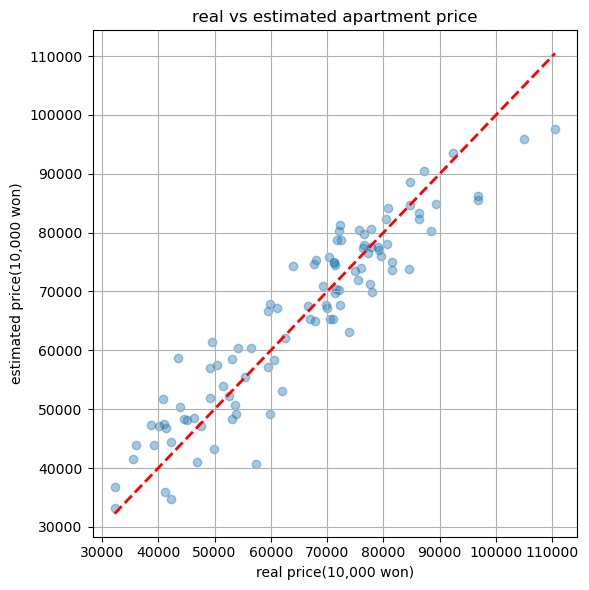

In [68]:
plt.figure(figsize=(6, 6))

# 산점도: x축 실제, y축 예측
plt.scatter(y_test, y_pred, alpha=0.4)

# y = x 기준선 (완벽 예측선)
min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2)

plt.xlabel("real price(10,000 won)")
plt.ylabel("estimated price(10,000 won)")
plt.title("real vs estimated apartment price")
plt.grid(True)
plt.tight_layout()
plt.show()

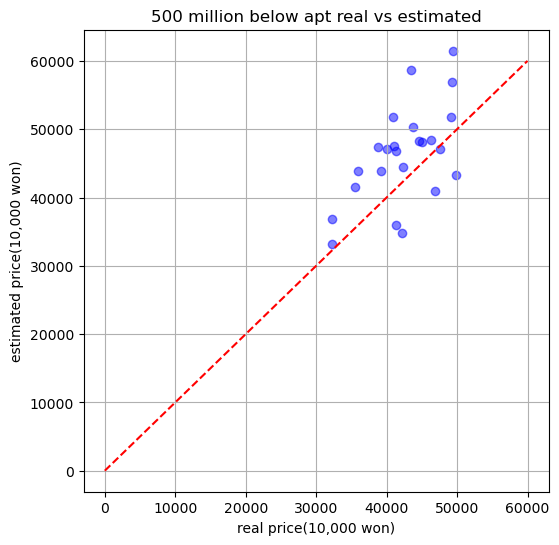

In [70]:
# 5억 이하(<=50,000)
mask_low = y_test <= 50000

plt.figure(figsize=(6,6))
plt.scatter(y_test[mask_low], y_pred[mask_low], alpha=0.5, color='blue')
plt.plot([0, 60000], [0, 60000], 'r--')
plt.title("500 million below apt real vs estimated")
plt.xlabel("real price(10,000 won)")
plt.ylabel("estimated price(10,000 won)")
plt.grid(True)
plt.show()

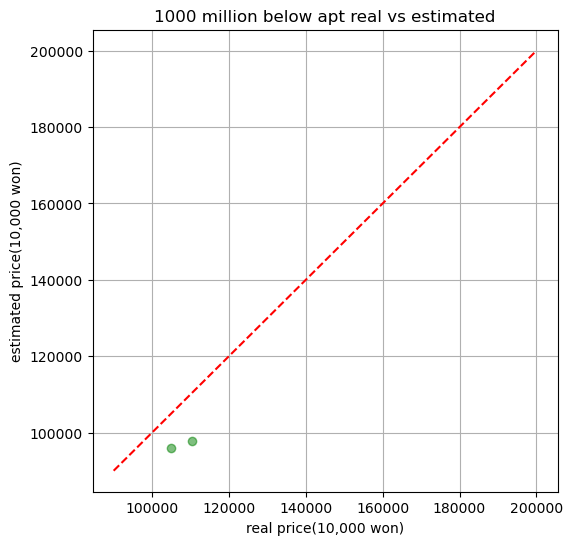

In [71]:
# 10억 이상(>=100,000)
mask_high = y_test >= 100000

plt.figure(figsize=(6,6))
plt.scatter(y_test[mask_high], y_pred[mask_high], alpha=0.5, color='green')
plt.plot([90000, 200000], [90000, 200000], 'r--')
plt.title("1000 million below apt real vs estimated")
plt.xlabel("real price(10,000 won)")
plt.ylabel("estimated price(10,000 won)")
plt.grid(True)
plt.show()

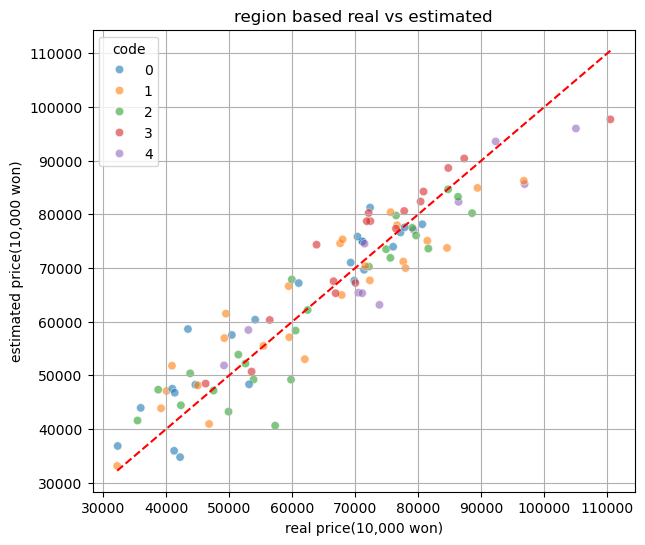

In [73]:
import seaborn as sns

# df_test : X_test index 기준으로 원본 데이터 위치 맞추기
df_test = df.loc[X_test.index]
df_test["code"] = df_test["지역코드"]
# (1) 지역 기반 색상
plt.figure(figsize=(7,6))
sns.scatterplot(
    x=y_test,
    y=y_pred,
    hue=df_test["code"],
    palette="tab10",
    alpha=0.6
)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         'r--')
plt.title("region based real vs estimated")
plt.xlabel("real price(10,000 won)")
plt.ylabel("estimated price(10,000 won)")
plt.grid(True)
plt.show()

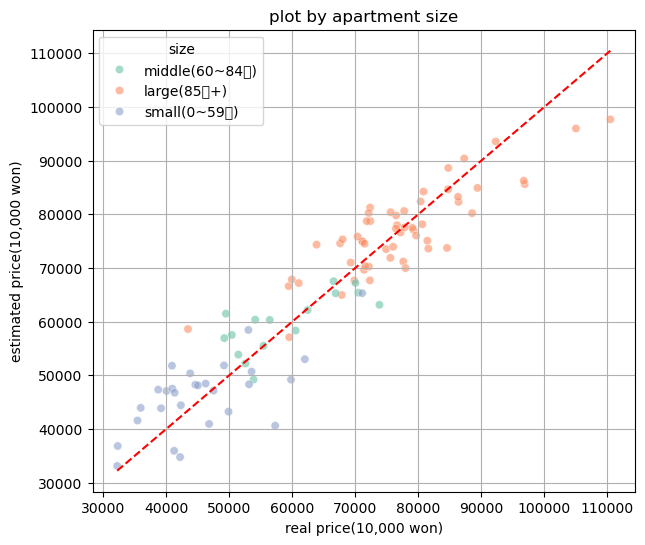

In [74]:
# (2) 평형대 만들기
def area_group(x):
    if x < 60:
        return "small(0~59㎡)"
    elif x <= 84:
        return "middle(60~84㎡)"
    else:
        return "large(85㎡+)"

df_test["size"] = df_test["전용면적"].apply(area_group)

# 평형대별 산점도
plt.figure(figsize=(7,6))
sns.scatterplot(
    x=y_test,
    y=y_pred,
    hue=df_test["size"],
    palette="Set2",
    alpha=0.6
)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         'r--')
plt.title("plot by apartment size")
plt.xlabel("real price(10,000 won)")
plt.ylabel("estimated price(10,000 won)")
plt.grid(True)
plt.show()

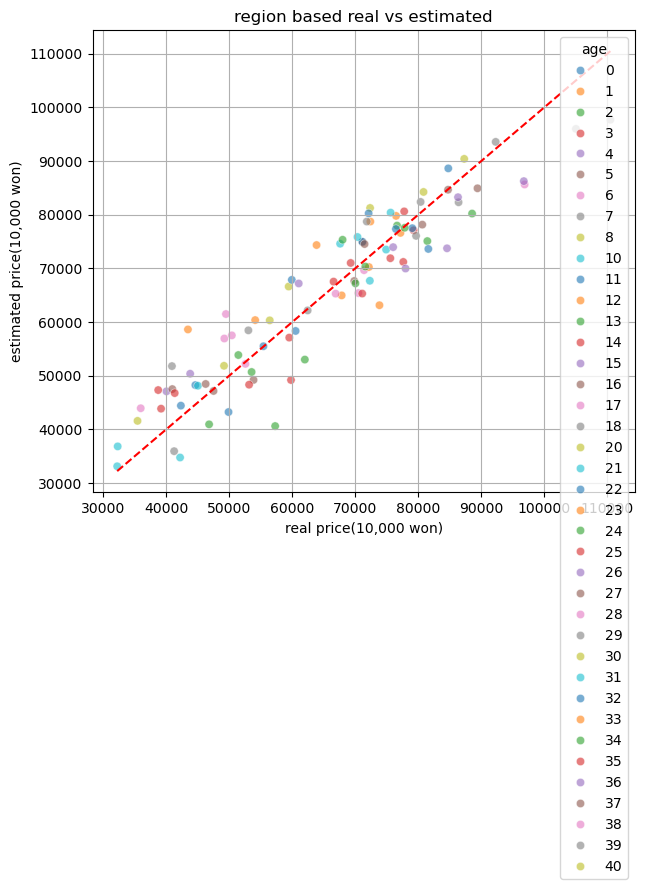

In [76]:
df_test = df.loc[X_test.index]
df_test["age"] = df_test["건물연식"]
# (1) 건물연식
plt.figure(figsize=(7,6))
sns.scatterplot(
    x=y_test,
    y=y_pred,
    hue=df_test["age"],
    palette="tab10",
    alpha=0.6
)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         'r--')
plt.title("region based real vs estimated")
plt.xlabel("real price(10,000 won)")
plt.ylabel("estimated price(10,000 won)")
plt.grid(True)
plt.show()

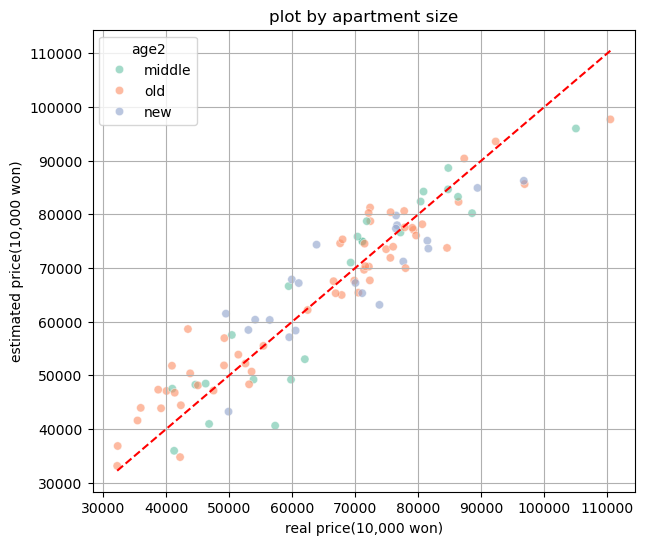

In [77]:
# (2) 평형대 만들기
def age_group(x):
    if x < 10:
        return "new"
    elif x <= 20:
        return "middle"
    else:
        return "old"

df_test["age2"] = df_test["건물연식"].apply(age_group)

# 평형대별 산점도
plt.figure(figsize=(7,6))
sns.scatterplot(
    x=y_test,
    y=y_pred,
    hue=df_test["age2"],
    palette="Set2",
    alpha=0.6
)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         'r--')
plt.title("plot by apartment size")
plt.xlabel("real price(10,000 won)")
plt.ylabel("estimated price(10,000 won)")
plt.grid(True)
plt.show()